In [1]:
import getpass
import os


def _set_env(key: str):
    if key not in os.environ:
        os.environ[key] = getpass.getpass(f"{key}:")


# _set_env("OPENAI_API_KEY")
_set_env("TAVILY_API_KEY")

In [11]:
### Retrieval Grader
from models import model
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import JsonOutputParser

In [3]:
import chromadb
client = chromadb.PersistentClient(
    path=r"C:\Users\luyer\my_rag\data"
)

In [4]:
collection = client.get_or_create_collection("my_movies")

In [5]:
results = collection.query(
    query_texts=["What is the director for Citizen Kane?"],
    n_results=3,
    include=["documents", "metadatas"],
)

for document, metadata in zip(
    results["documents"][0],
    results["metadatas"][0]
):
    
    print("Source:", metadata)
    print(document)
    print("-" * 60)

Source: {'creationdate': '2026-08-25T22:32:40+00:00', 'producer': 'Skia/PDF m151', 'title': 'Citizen Kane - Wikipedia', 'total_pages': 50, 'source': 'C:\\Users\\luyer\\my_rag\\data\\Citizen_Kane.pdf', 'page': 49, 'page_label': '50', 'creator': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) HeadlessChrome/151.0.0.0 Safari/537.36', 'moddate': '2026-08-25T22:32:40+00:00', 'start_index': 0}
Citizen Kane and Bernard Herrmann's film score (http://www.americanmusicpreservation.co
m/CitizenKanefilmscore.htm)
PBS: Citizen Kane (https://www.pbs.org/wgbh/americanexperience/films/kane2/) (Archived)
Bright Lights Film Journal Essay (http://arquivo.pt/wayback/20090713051923/http://www.bri
ghtlightsfilm.com/45/kane.htm)
Roger Ebert: Citizen Kane (https://web.archive.org/web/20120711082553/http://rogerebert.s
untimes.com/apps/pbcs.dll/article?AID=%2F19980524%2FREVIEWS08%2F401010334%2
F1023)
The Unofficial Citizen Kane Page (http://hem.bredband.net/b139242)
Time Magazine Top 10

c:\Users\luyer\my_rag\rag_design\custom_graph.py:91: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(k=3)


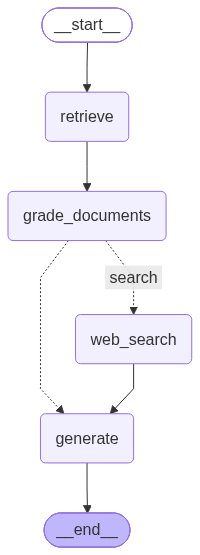

In [7]:
from IPython.display import Image, display
from custom_graph import custom_graph

display(Image(custom_graph.get_graph(xray=True).draw_mermaid_png()))

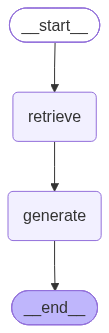

In [15]:
from IPython.display import Image, display
from custom_graph_no_web_search import custom_graph

display(Image(custom_graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
from rag_design.custom_graph import predict_custom_agent_local_answer

example = {"input": "who directed movie Parasite?"}
response = predict_custom_agent_local_answer(example)
response

{'response': 'Bong Joon-ho directed the movie Parasite. He also co-wrote the screenplay with Han Jin-won. The 2019 South Korean black comedy thriller went on to win numerous prestigious awards, including the Academy Award for Best Picture.',
 'steps': ['retrieve_documents',
  'grade_document_retrieval',
  'web_search',
  'generate_answer']}

In [8]:
from custom_graph import target

# target is imported from custom_graph for LangSmith evaluation

In [16]:
from custom_graph_no_web_search import target

# target is imported from custom_graph for LangSmith evaluation